<a href="https://colab.research.google.com/github/helonayala/sysid/blob/main/narmax_example_drone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NARX model

NARX model for the 1/4 drone dataset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Install/import the sysid course library (works locally and on Google Colab) ---
try:
    from sysid import NARX, readData
except ImportError:
    !pip install -q git+https://github.com/helonayala/sysid.git
    from sysid import NARX, readData


## Load and preprocess the datasets

Closed-loop 1/4 drone acquisitions. Each signal is sliced to a fixed useful time window (20–80 s) and decimated by a common factor, then stored in a `data` dictionary.

In [2]:
DECIMATION = 5
T_START, T_END = 20.0, 80.0   # hard-coded useful window [s]

def load_processed(name, t0=T_START, t1=T_END, decimation=DECIMATION):
    """Load a 1/4 drone dataset, keep t in [t0, t1] s and decimate. Returns u, y, t, ref."""
    y, u, t, ref = readData('quarter_drone', name, return_ref=True)
    idx = np.where((t >= t0) & (t <= t1))[0]
    sl = slice(idx[0], idx[-1] + 1, decimation)
    return u[sl], y[sl], t[sl], ref[sl]

def plot_io(u, y, t, ref, title):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
    ax1.plot(t, ref, '--', color='red', label='Referência')
    ax1.plot(t, y, color='blue', label='Saída y')
    ax1.set_ylabel('Ângulo [°]'); ax1.set_title(title)
    ax1.legend(loc='upper right'); ax1.grid(True)
    ax2.plot(t, u, color='green', label='Controle u')
    ax2.set_xlabel('Tempo [s]'); ax2.set_ylabel('u')
    ax2.legend(loc='upper right'); ax2.grid(True)
    plt.tight_layout(); plt.show()

data = {
    'multisine':  load_processed('multiseno'),
    'swept_sine': load_processed('swept_sine'),
    'steps':      load_processed('degraus'),
}


## Processed datasets

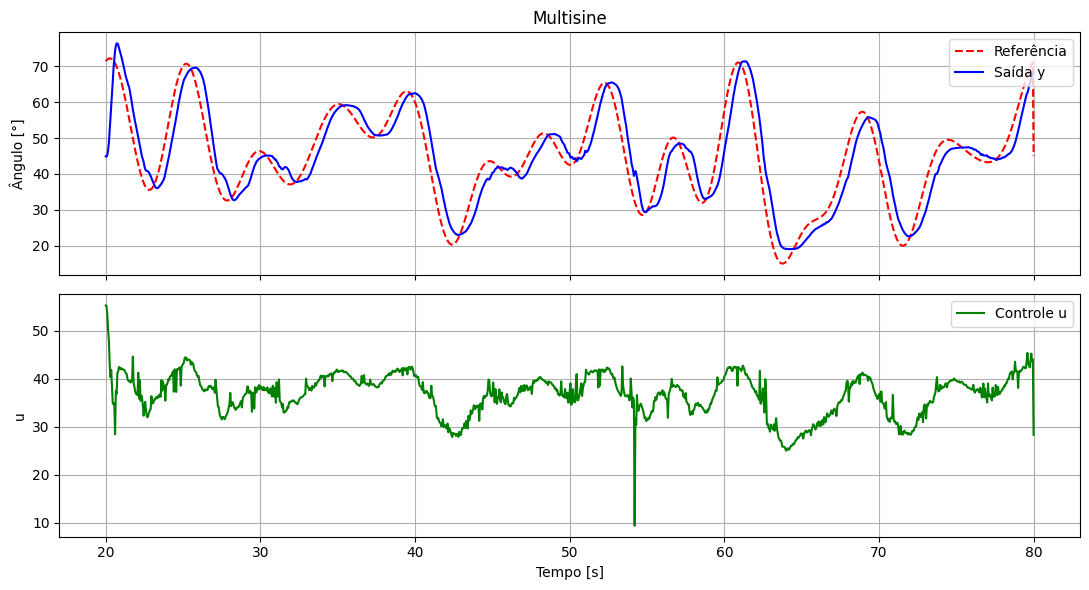

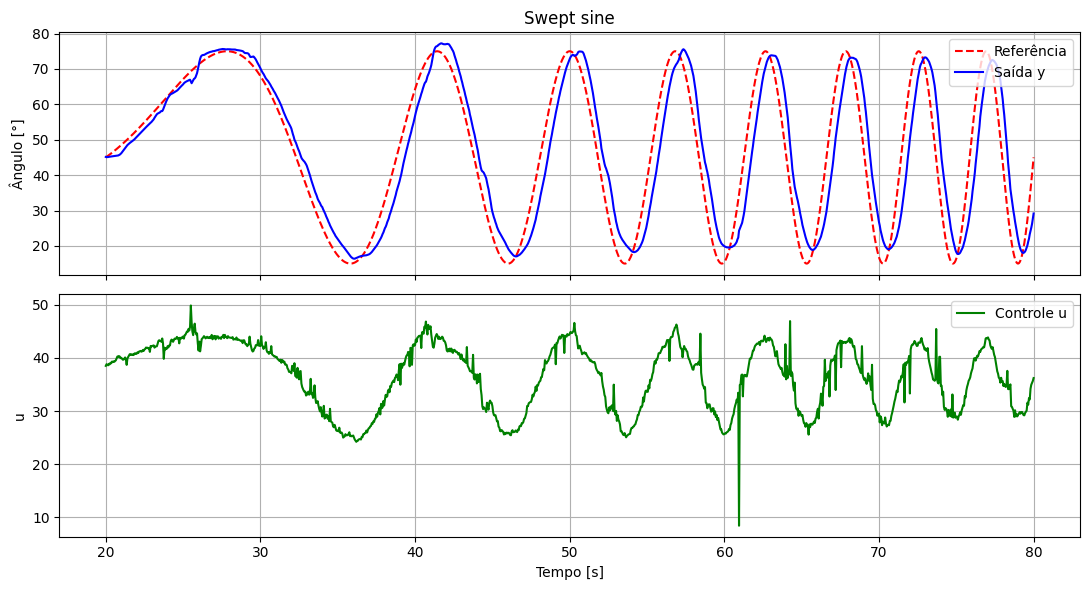

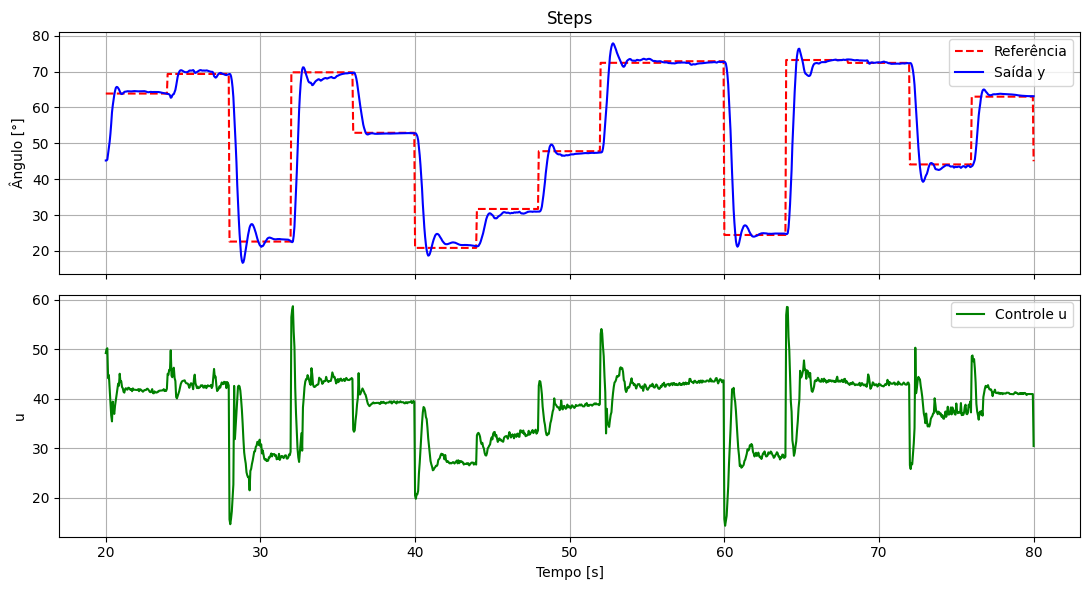

In [3]:
plot_io(*data['multisine'],  'Multisine')
plot_io(*data['swept_sine'], 'Swept sine')
plot_io(*data['steps'],      'Steps')


## Train / test split

Protocol:
- **multisine** and **steps**: first **80%** for training, last **20%** for test;
- **swept sine**: used **entirely for test** (never seen during identification).

The model is identified jointly from the two training portions (`fit` takes a list of `(u, y)` pairs and stacks their regression matrices).

In [4]:
TRAIN_FRAC = 0.8

def split_idx(name, frac=TRAIN_FRAC):
    u, y, t, ref = data[name]
    return int(len(y) * frac)

k_mult  = split_idx('multisine')
k_steps = split_idx('steps')

u_m, y_m = data['multisine'][0], data['multisine'][1]
u_s, y_s = data['steps'][0],     data['steps'][1]

train_data = [
    (u_m[:k_mult],  y_m[:k_mult]),    # multisine 80%
    (u_s[:k_steps], y_s[:k_steps]),   # steps 80%
]


## Model identification (multiple datasets)

In [7]:
ny_model = 5
nu_model = 5
poly_order_model = 2
n_components = 10

narx_model = NARX(nu=nu_model, ny=ny_model, poly_order_l=poly_order_model,
                  n_components=n_components)
narx_model.fit(train_data)
narx_model.print()


NARX model — selected terms and parameters
Max lag: 5  (ny=5, nu=5, l=2)
#    Term                                theta     ERR (%)
-------------------------------------------------------
1    y(k-1)                             1.4939   99.966165
2    y(k-2)                            -0.3345    0.031282
3    u(k-2)u(k-3)                       0.0006    0.000981
4    y(k-1)u(k-5)                       0.0002    0.000199
5    y(k-3)                            -0.0291    0.000116
6    u(k-4)u(k-5)                       0.0006    0.000015
7    y(k-1)y(k-1)                       0.0002    0.000042
8    y(k-4)                            -0.1709    0.000038
9    y(k-1)u(k-4)                      -0.0003    0.000015
10   u(k-1)u(k-5)                      -0.0002    0.000006
-------------------------------------------------------
Total ERR explained:                 99.998860%


## Final evaluation

Free-run simulation over each **entire** dataset. The shaded region marks the **test** part (last 20% for multisine/steps; the whole signal for swept sine). The reported RMSE is computed on the test region.

Starting Free-Run Simulation for 1196 steps...


FR Simulation:   0%|          | 0/1196 [00:00<?, ?step/s]

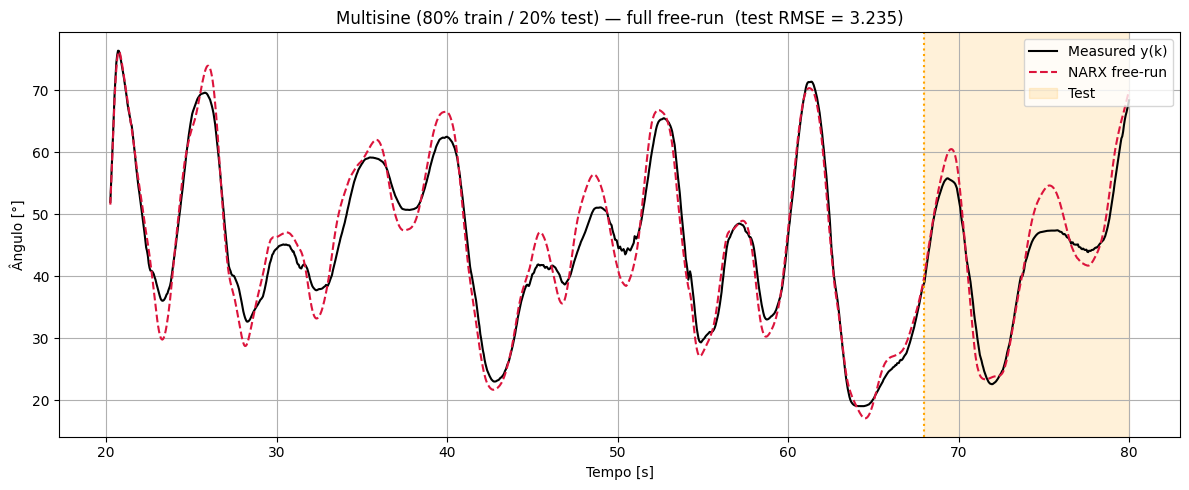

Starting Free-Run Simulation for 1196 steps...


FR Simulation:   0%|          | 0/1196 [00:00<?, ?step/s]

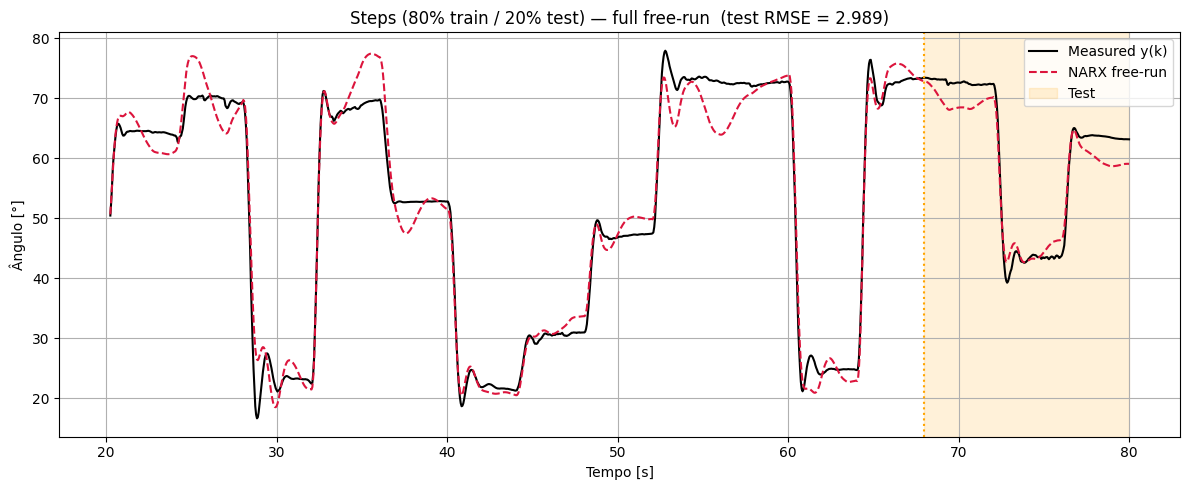

Starting Free-Run Simulation for 1196 steps...


FR Simulation:   0%|          | 0/1196 [00:00<?, ?step/s]

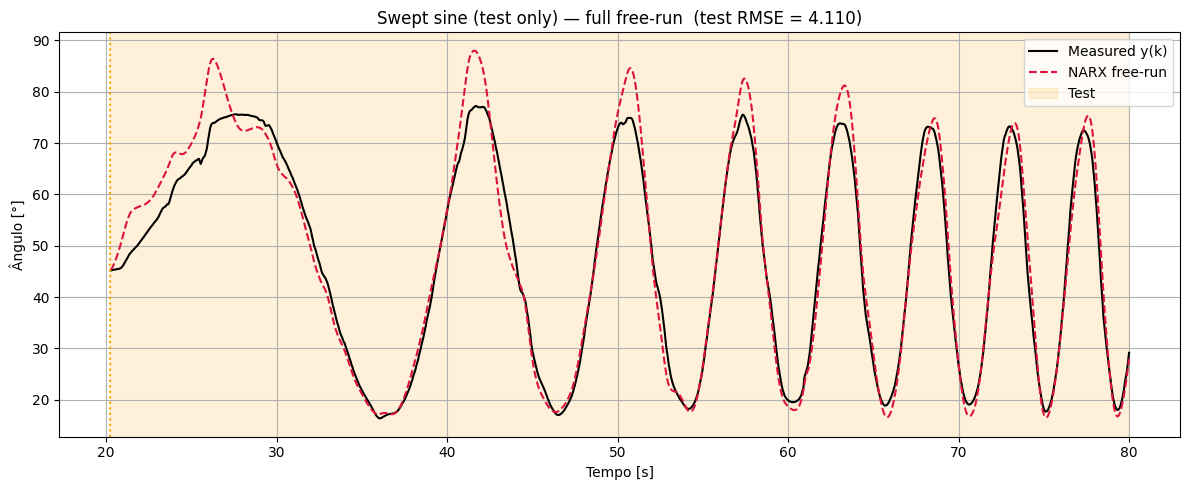

In [10]:
def free_run_full(name, k_split=None, title=None):
    u, y, t, ref = data[name]
    ml = narx_model._max_lag_internal_
    y_fr = narx_model.predict(u, y_history_for_lags_or_osa=y[:ml], mode='FR')
    tt, ym = t[ml:], y[ml:]
    t_split = t[k_split] if k_split is not None else tt[0]
    test_mask = tt >= t_split
    rmse_test = np.sqrt(np.mean((ym[test_mask] - y_fr[test_mask]) ** 2))
    plt.figure(figsize=(12, 5))
    plt.plot(tt, ym, color='black', label='Measured y(k)')
    plt.plot(tt, y_fr, '--', color='crimson', label='NARX free-run')
    plt.axvspan(t_split, tt[-1], color='orange', alpha=0.15, label='Test')
    plt.axvline(t_split, color='orange', ls=':')
    plt.xlabel('Tempo [s]'); plt.ylabel('Ângulo [°]')
    plt.title(f'{title or name} — full free-run  (test RMSE = {rmse_test:.3f})')
    plt.legend(loc='upper right'); plt.grid(True)
    plt.tight_layout(); plt.show()

free_run_full('multisine', k_mult, 'Multisine (80% train / 20% test)')
free_run_full('steps',     k_steps, 'Steps (80% train / 20% test)')
free_run_full('swept_sine', None,  'Swept sine (test only)')
